# (Work in Progress)
Split .mseed file into small time windows, and test inference of p and s picker models (EQCCT)

Finally plots waveforms with predicted p- and s-wave picks

#### Instructions: 
First you must provide at least one .mseed file. \
In this example, the data from 18th May 2020 of station Hetta (HEF) in Finland was used, as there was at least one strong earthquake nearby in Kiruna, Sweden. \
Files can be downloaded from here: https://geofon.gfz.de/waveform/archive/network.php?ncode=HE

Move the .mseed file(s) to the "mseed_raw"-directory and the following cell will split the file(s) into 2-minute (default) chunks. \
The generated files are written to "mseed_processed/{station code}" directory.

In [ ]:
from obspy import read, UTCDateTime
import os
import glob

# Helper function for time formatting
def format_time(t):
    return t.strftime("%Y-%m-%dT%H_%M_%S.%fZ")

# Read mseed file, split into windows of chosen length
# and store each component (E,N,Z) into separate files

# ===USER SETTINGS===
input_dir = "mseed_raw/"
output_dir = "./mseed_processed"
window_length = 120  # 2 minutes
# =====================

for input_path in glob.glob(os.path.join(input_dir, "*.mseed")):
    # Load mseed
    st = read(input_path)
    
    # Determine the network and station
    network = st[0].stats.network
    station = st[0].stats.station

    # Create the output directory for the file (each station in a different subfolder)
    os.makedirs(os.path.join(output_dir, station), exist_ok=True)

    # Make sure traces are aligned
    st.merge(method=1, fill_value="interpolate")

    # Determine global time span
    global_start = max(tr.stats.starttime for tr in st)
    global_end = min(tr.stats.endtime for tr in st)

    print(f"Waveform data from: {global_start} to {global_end}")

    # Sliding window loop
    current_start = global_start

    while current_start + window_length <= global_end:
        current_end = current_start + window_length

        st_window = st.copy().trim(starttime=current_start,
                                endtime=current_end)

        # Skip empty chunks (just in case)
        if len(st_window) == 0:
            current_start += window_length
            continue

        start_str = format_time(current_start)
        end_str = format_time(current_end)

        for tr in st_window:
            channel = tr.stats.channel[-1]  # E/N/Z

            filename = f"{network}.{station}.{channel}__{start_str}__{end_str}.mseed"
            filepath = os.path.join(output_dir, station, filename)

            tr.write(filepath, format="MSEED")

        current_start += window_length

    print(f'Input .mseed file "{input_path}" successfully split into {window_length} second windows.')

Waveform data from: 2020-05-17T23:59:57.450000Z to 2020-05-18T23:59:59.900000Z
Input .mseed file "mseed_raw/fdsnws.mseed" successfully split into 120 second windows.


## Inference
Run inference for the separate p-picker and s-picker models and store the predictions in a .csv file in "detectionsCustom"-directory.

In [43]:
from eqcct.utils import *
os.system('rm -rf ./detectionsCustom')

json_basepath = os.path.join(os.getcwd(),"Example_Custom_station_list.json")

mseed_predictor_two(input_dir=output_dir,   
         input_modelP='../ModelPS/test_trainer_024.h5',
         input_modelS='../ModelPS/test_trainer_021.h5',
         stations_json=json_basepath,
         output_dir='./detectionsCustom',
         P_threshold=0.1,
         S_threshold=0.1, 
         number_of_plots=10,
         normalization_mode='std',
         batch_size=1,
         overlap=0.8,
         gpuid=None,
         gpu_limit=None) 

02-14 17:09 [INFO] [EQCCT_Picker] Running EQCCT_Picker
02-14 17:09 [INFO] [EQCCT_Picker] *** Loading the model ...


Model: "model_11"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input (InputLayer)             [(None, 6000, 3)]    0           []                               
                                                                                                  
 conv1d_135 (Conv1D)            (None, 6000, 3)      102         ['input[0][0]']                  
                                                                                                  
 batch_normalization_135 (Batch  (None, 6000, 3)     12          ['conv1d_135[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 activation_135 (Activation)    (None, 6000, 3)      0           ['batch_normalization_135[

02-14 17:09 [INFO] [EQCCT_Picker] *** Loading is complete!
02-14 17:09 [INFO] [EQCCT_Picker] There are files for 1 stations in ./mseed_processed directory.
02-14 17:09 [INFO] [EQCCT_Picker] Started working on HEF, 1 out of 1 ...
02-14 17:09 [INFO] [EQCCT_Picker] 2020-05-17T23_59_57.450000Z__2020-05-18T00_01_57.450000Z.mseed
02-14 17:09 [INFO] [EQCCT_Picker] 2020-05-18T00_01_57.450000Z__2020-05-18T00_03_57.450000Z.mseed
02-14 17:09 [INFO] [EQCCT_Picker] 2020-05-18T00_03_57.450000Z__2020-05-18T00_05_57.450000Z.mseed
02-14 17:09 [INFO] [EQCCT_Picker] 2020-05-18T00_05_57.450000Z__2020-05-18T00_07_57.450000Z.mseed
02-14 17:09 [INFO] [EQCCT_Picker] 2020-05-18T00_07_57.450000Z__2020-05-18T00_09_57.450000Z.mseed
02-14 17:09 [INFO] [EQCCT_Picker] 2020-05-18T00_09_57.450000Z__2020-05-18T00_11_57.450000Z.mseed
02-14 17:09 [INFO] [EQCCT_Picker] 2020-05-18T00_11_57.450000Z__2020-05-18T00_13_57.450000Z.mseed
02-14 17:09 [INFO] [EQCCT_Picker] 2020-05-18T00_13_57.450000Z__2020-05-18T00_15_57.450000Z.m

02-14 17:10 [INFO] [EQCCT_Picker] Finished the prediction in: 0 hours and 1 minutes and 23.7 seconds.
02-14 17:10 [INFO] [EQCCT_Picker] *** Detected: 4320 events.
02-14 17:10 [INFO] [EQCCT_Picker]  *** Wrote the results into --> " /home/tomc/projects/eqcct-1/eqcctone/notebooks/./detectionsCustom/HEF_outputs "


## Load predictions into DataFrame

In [44]:
import pandas as pd
import numpy as np

# Load the predictions
data = pd.read_csv(f'./detectionsCustom/{station}_outputs/X_prediction_results.csv', low_memory=False)

# Print all rows with predicted picks
data.loc[data["p_probability"].notna() | data["s_probability"].notna()]

,file_name,network,station,instrument_type,station_lat,station_lon,station_elv,p_arrival_time,p_probability,s_arrival_time,s_probability
67,HEF/HE.HEF.Z__2020-05-18T00_21_57.450000Z__202...,0,HEF,0,0,0,0,2020-05-18 00:22:42.760000,0.576,NaN,NaN
68,HEF/HE.HEF.Z__2020-05-18T00_21_57.450000Z__202...,0,HEF,0,0,0,0,2020-05-18 00:22:42.660000,0.432,2020-05-18 00:23:00.890000,0.158
69,HEF/HE.HEF.Z__2020-05-18T00_21_57.450000Z__202...,0,HEF,0,0,0,0,2020-05-18 00:22:42.450000,0.876,2020-05-18 00:23:00.910000,0.313
83,HEF/HE.HEF.Z__2020-05-18T00_25_57.450000Z__202...,0,HEF,0,0,0,0,2020-05-18 00:27:06.450000,0.334,NaN,NaN
105,HEF/HE.HEF.Z__2020-05-18T00_33_57.450000Z__202...,0,HEF,0,0,0,0,NaN,NaN,2020-05-18 00:35:11.180000,0.136
106,HEF/HE.HEF.Z__2020-05-18T00_33_57.450000Z__202...,0,HEF,0,0,0,0,2020-05-18 00:34:50.230000,0.218,2020-05-18 00:35:11.170000,0.222
217,HEF/HE.HEF.Z__2020-05-18T01_11_57.450000Z__202...,0,HEF,0,0,0,0,2020-05-18 01:12:21.420000,0.482,2020-05-18 01:12:40.920000,0.294
218,HEF/HE.HEF.Z__2020-05-18T01_11_57.450000Z__202...,0,HEF,0,0,0,0,NaN,NaN,2020-05-18 01:12:40.970000,0.287
256,HEF/HE.HEF.Z__2020-05-18T01_23_57.450000Z__202...,0,HEF,0,0,0,0,2020-05-18 01:25:14.230000,0.352,NaN,NaN
257,HEF/HE.HEF.Z__2020-05-18T01_23_57.450000Z__202...,0,HEF,0,0,0,0,2020-05-18 01:25:14.380000,0.250,2020-05-18 01:25:35.880000,0.200


In [45]:
# Print all unique filenames and number of mseed files
name = (np.unique(data['file_name']))
print(f"Complete list of filenames:\n{name}\n")
print(f"Number of files: {len(name)}")

Complete list of filenames:
['HEF/HE.HEF.Z__2020-05-17T23_59_57.450000Z__2020-05-18T00_01_57.450000Z.mseed'
 'HEF/HE.HEF.Z__2020-05-18T00_01_57.450000Z__2020-05-18T00_03_57.450000Z.mseed'
 'HEF/HE.HEF.Z__2020-05-18T00_03_57.450000Z__2020-05-18T00_05_57.450000Z.mseed'
 'HEF/HE.HEF.Z__2020-05-18T00_05_57.450000Z__2020-05-18T00_07_57.450000Z.mseed'
 'HEF/HE.HEF.Z__2020-05-18T00_07_57.450000Z__2020-05-18T00_09_57.450000Z.mseed'
 'HEF/HE.HEF.Z__2020-05-18T00_09_57.450000Z__2020-05-18T00_11_57.450000Z.mseed'
 'HEF/HE.HEF.Z__2020-05-18T00_11_57.450000Z__2020-05-18T00_13_57.450000Z.mseed'
 'HEF/HE.HEF.Z__2020-05-18T00_13_57.450000Z__2020-05-18T00_15_57.450000Z.mseed'
 'HEF/HE.HEF.Z__2020-05-18T00_15_57.450000Z__2020-05-18T00_17_57.450000Z.mseed'
 'HEF/HE.HEF.Z__2020-05-18T00_17_57.450000Z__2020-05-18T00_19_57.450000Z.mseed'
 'HEF/HE.HEF.Z__2020-05-18T00_19_57.450000Z__2020-05-18T00_21_57.450000Z.mseed'
 'HEF/HE.HEF.Z__2020-05-18T00_21_57.450000Z__2020-05-18T00_23_57.450000Z.mseed'
 'HEF/HE.HEF

## Select and filter p- and s-wave picks based on predicted probability
If there are not enough (or too many), try changing the probability threshold or filtering condition.

In [46]:
import os
import glob
import numpy as np
import pandas as pd
import obspy
from obspy import UTCDateTime
import matplotlib.pyplot as plt

# ===USER SETTINGS====
# Threshold for predicted p- and s-wave pick probability (Possible range: 0 to 1.0)
p_threshold = 0.4
s_threshold = 0.4
filter_condition = "or"     # Can also choose "and"
# =====================

# Load prediction results
df = pd.read_csv(f'./detectionsCustom/{station}_outputs/X_prediction_results.csv', low_memory=False)

if filter_condition == "or":
    # Keep rows where either threshold is met
    df_filtered = df[(df['p_probability'] > p_threshold) | (df['s_probability'] > s_threshold)]
elif filter_condition == "and":
    # Keep rows where both thresholds are met
    df_filtered = df[(df['p_probability'] > p_threshold) & (df['s_probability'] > s_threshold)]
else:
    raise ValueError("Filter condition must be 'and' or 'or'.")

print(f"Found {len(df_filtered)} windows with predicted P-/S-arrivals.")

Found 20 windows with predicted P-/S-arrivals.


## Plot the filtered waveforms alonside the predicted picks

02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved


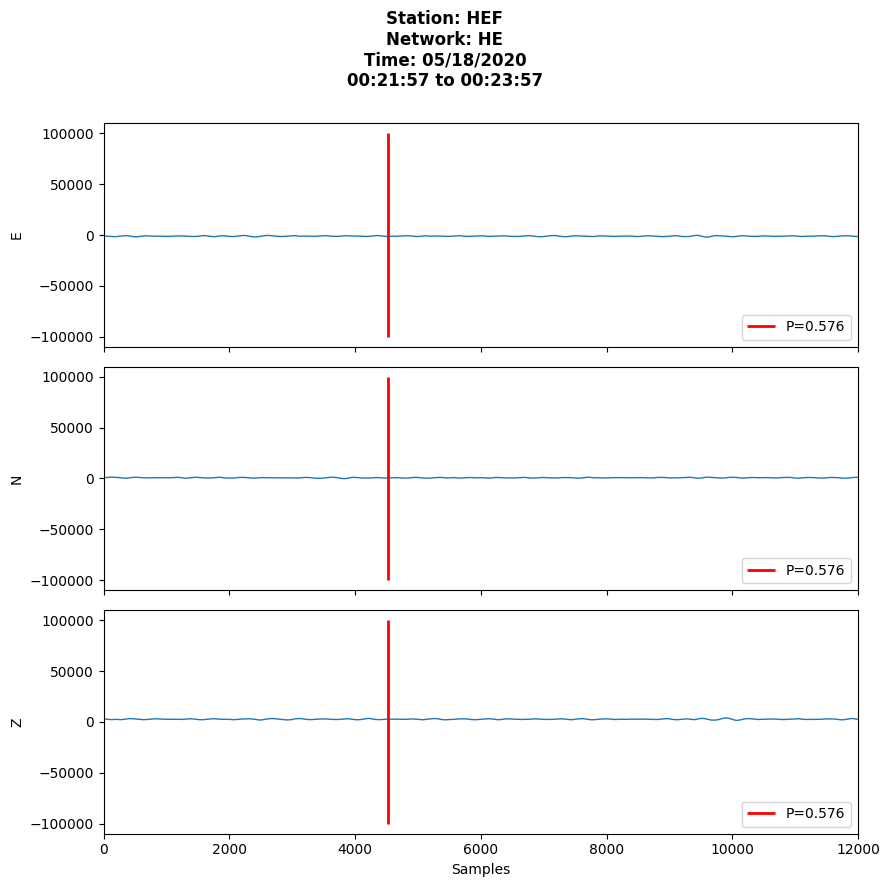

02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved


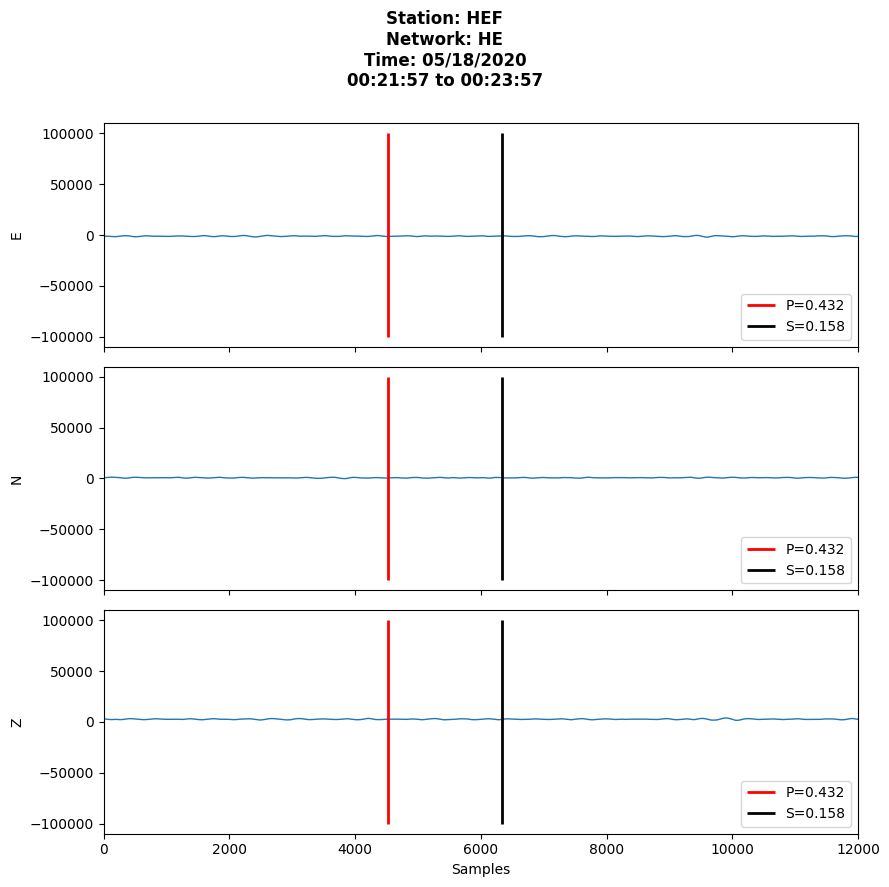

02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved


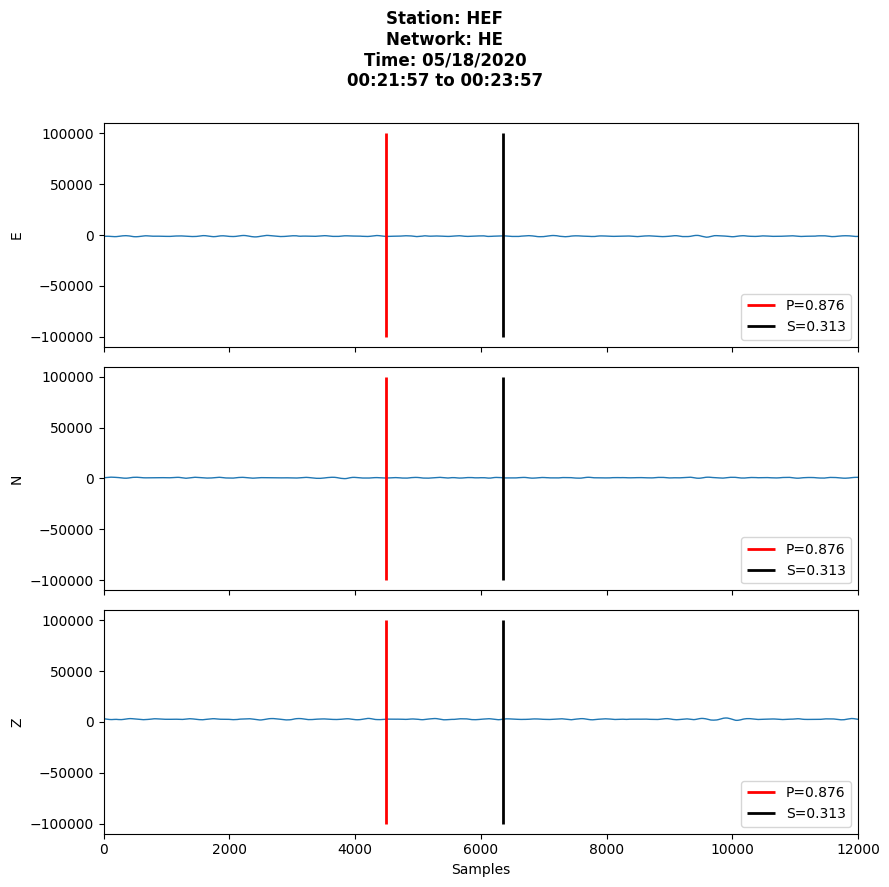

02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved


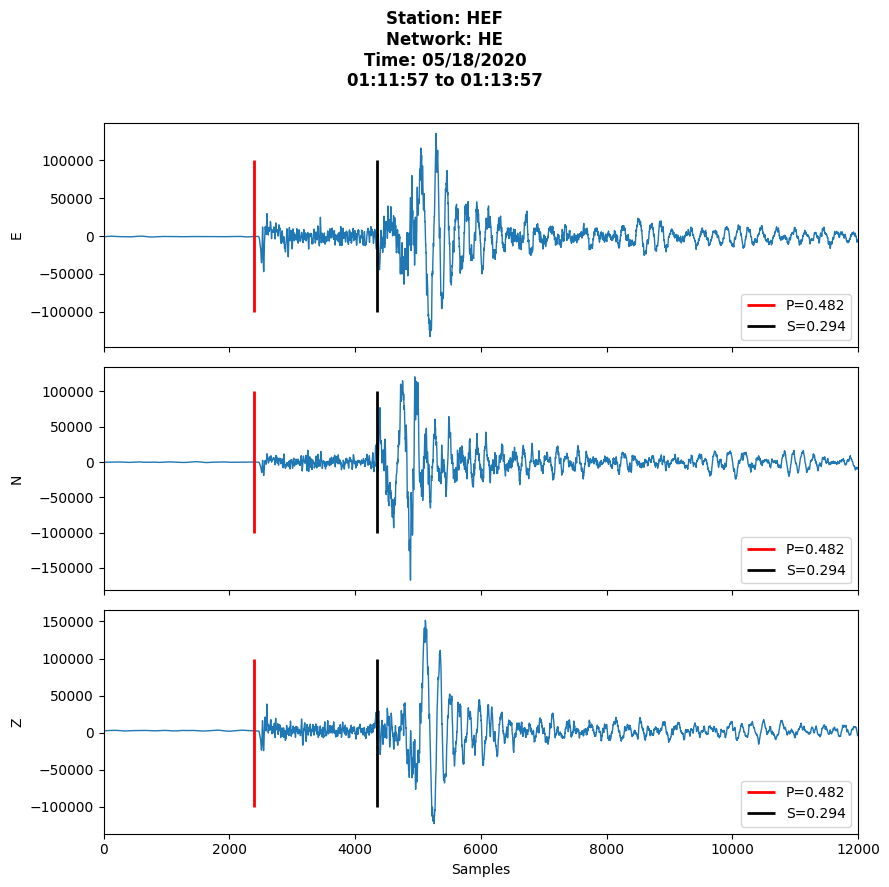

02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved


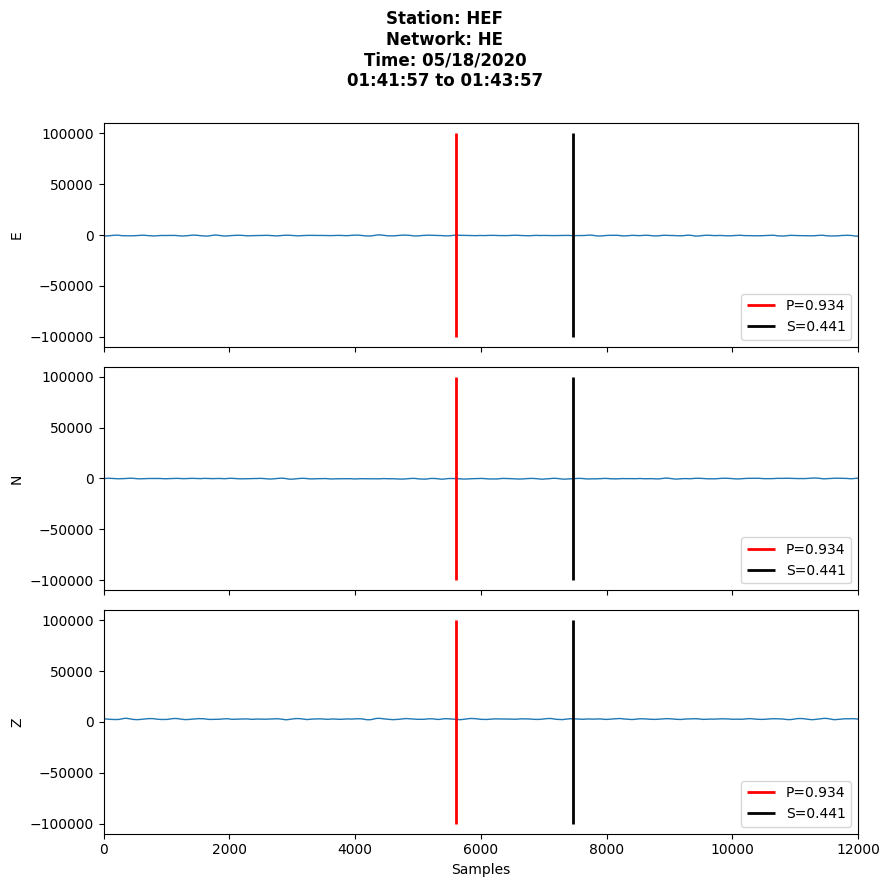

02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved


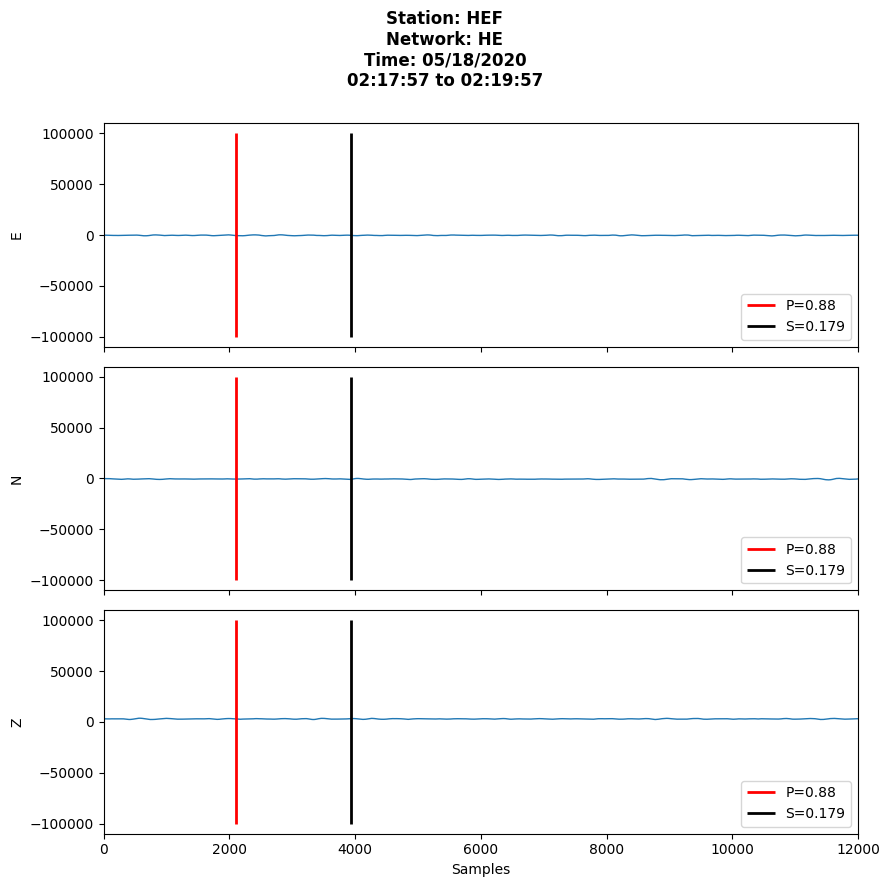

02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved


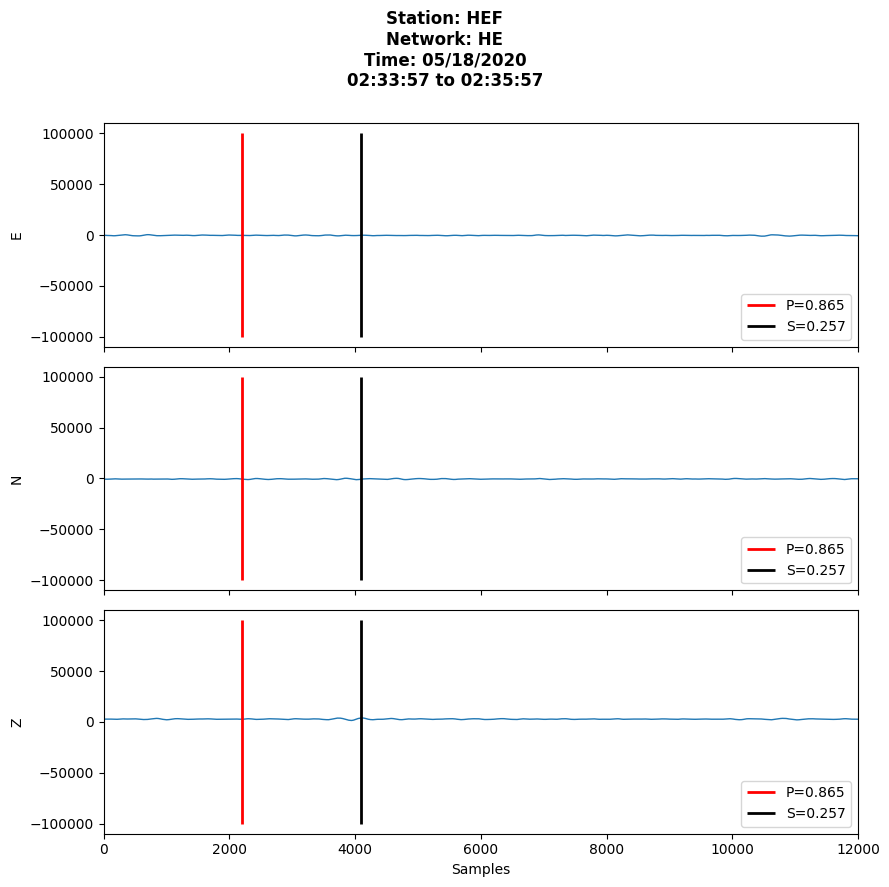

02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved


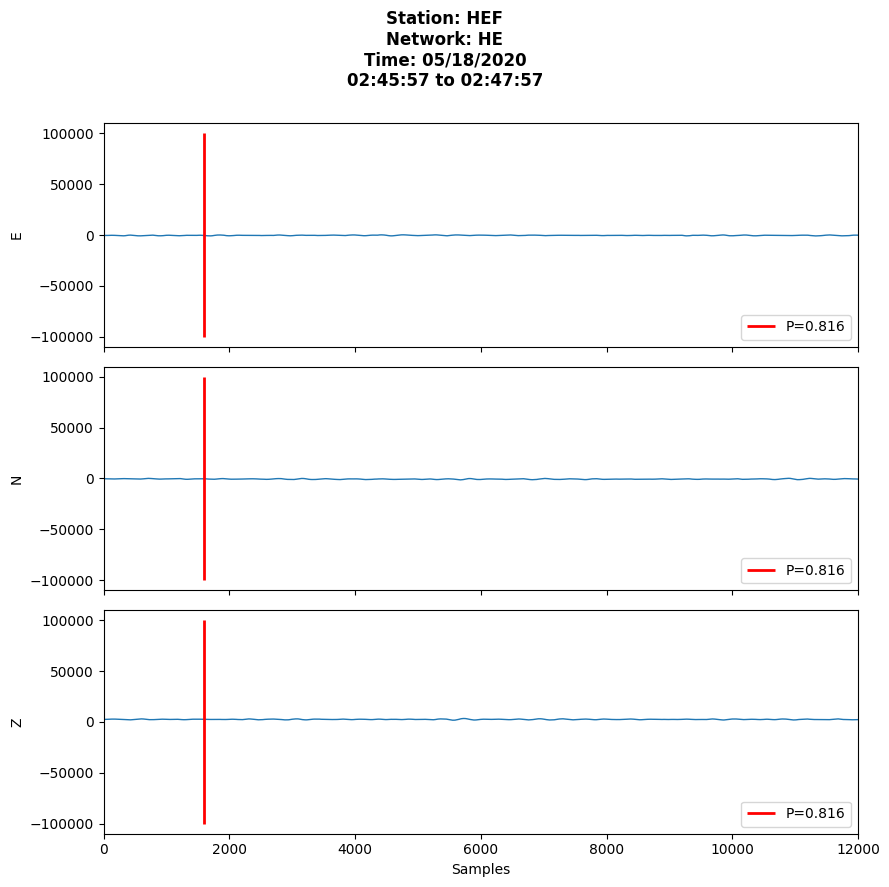

02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved


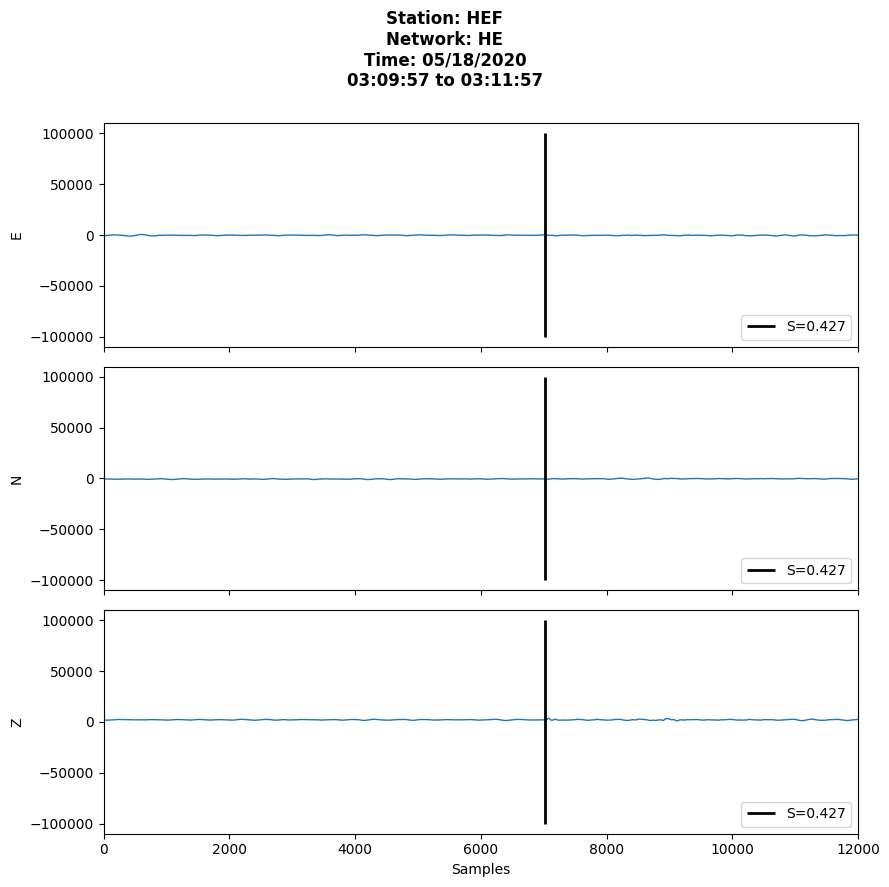

02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved


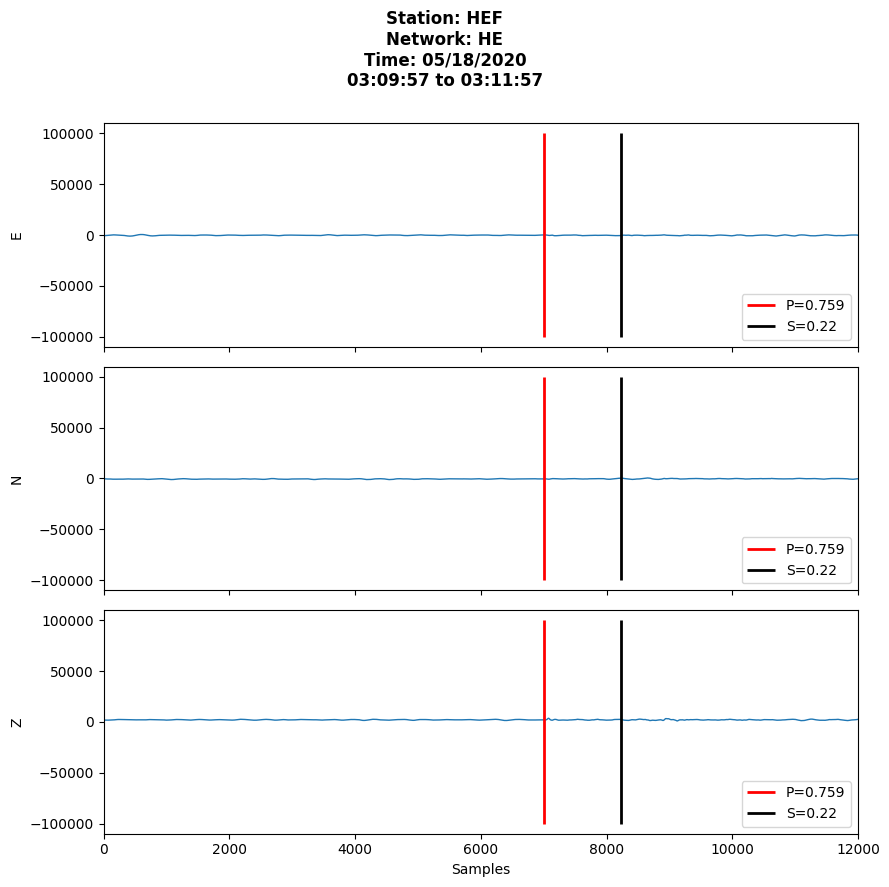

02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved


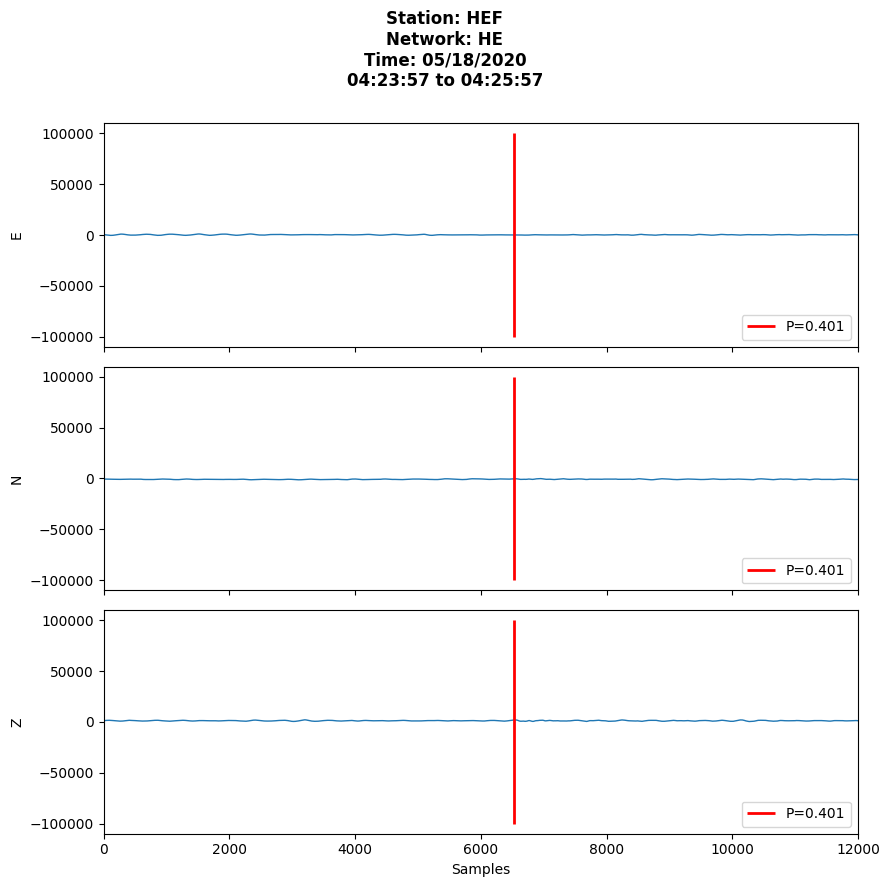

02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved


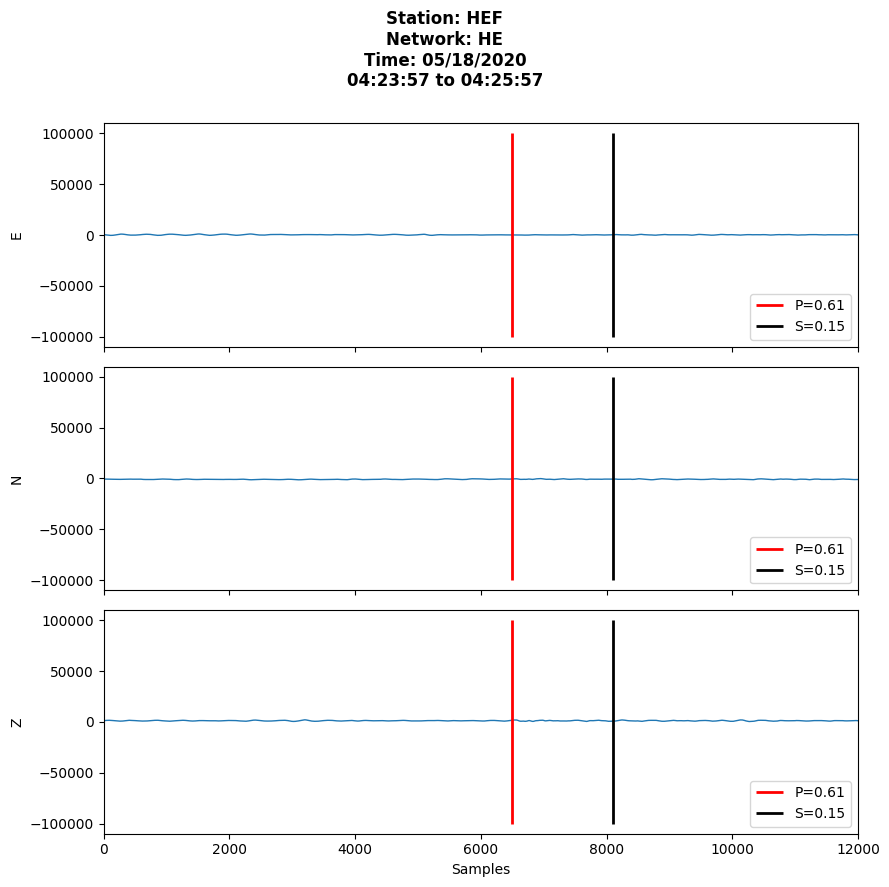

02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved


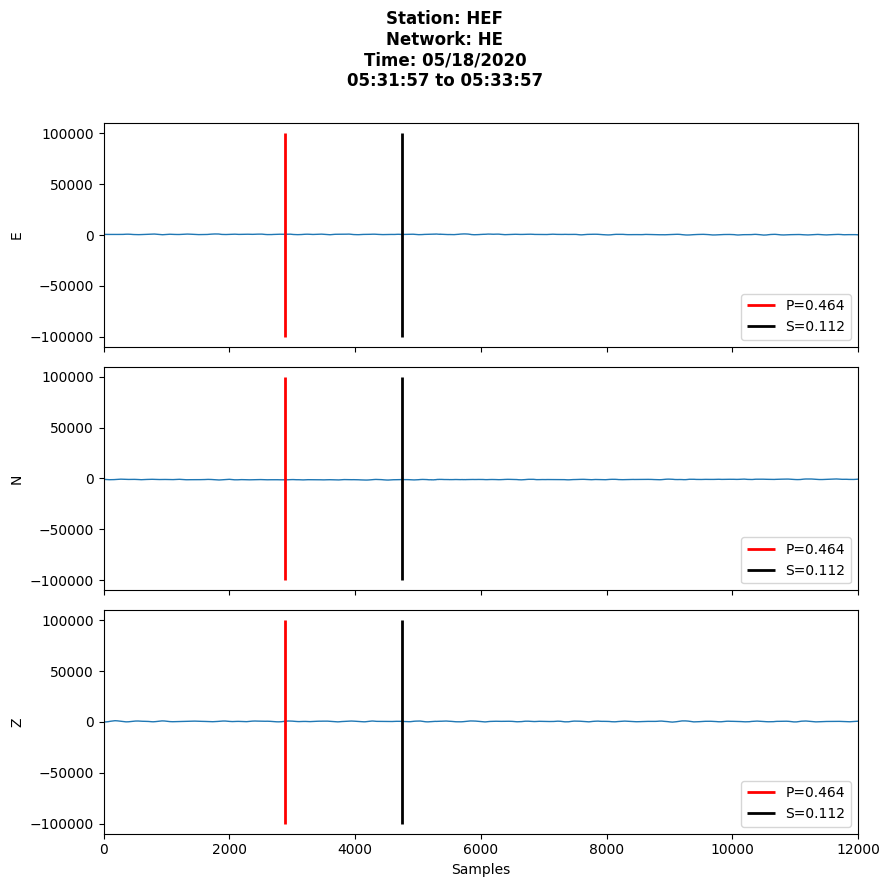

02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved


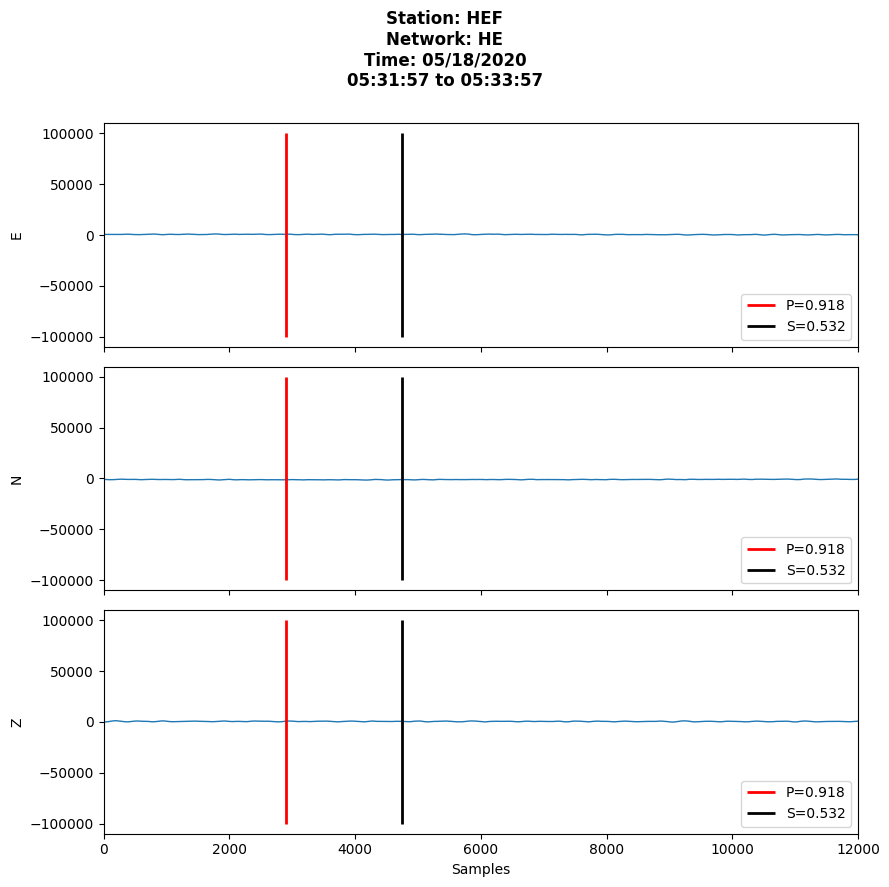

02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved


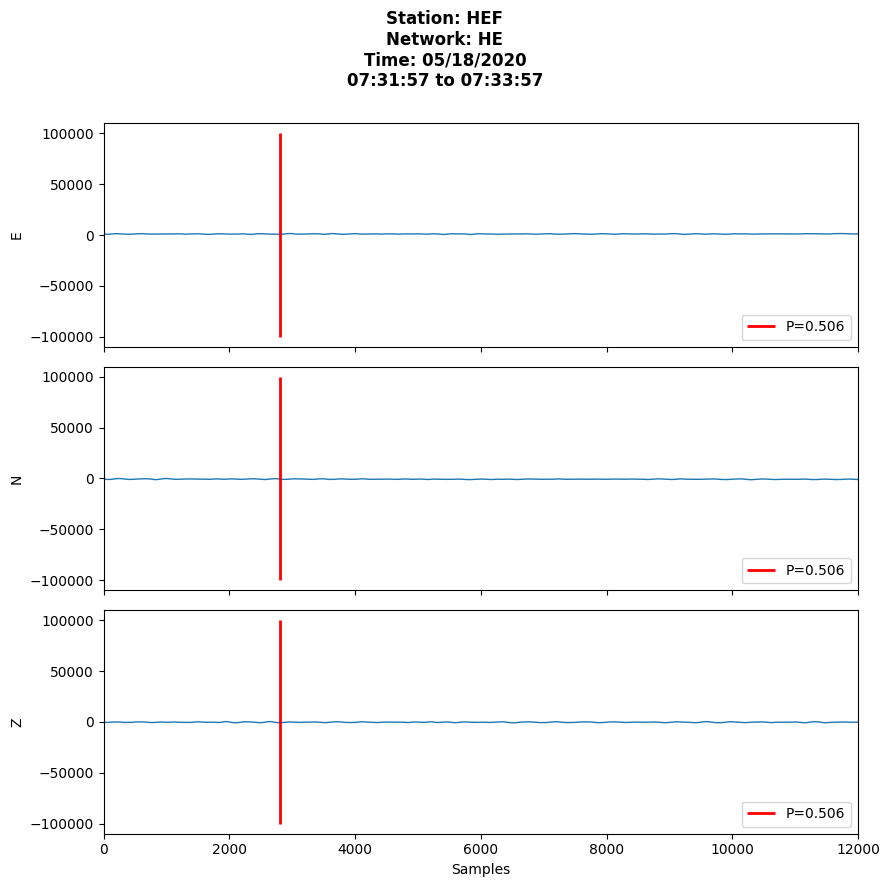

02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved


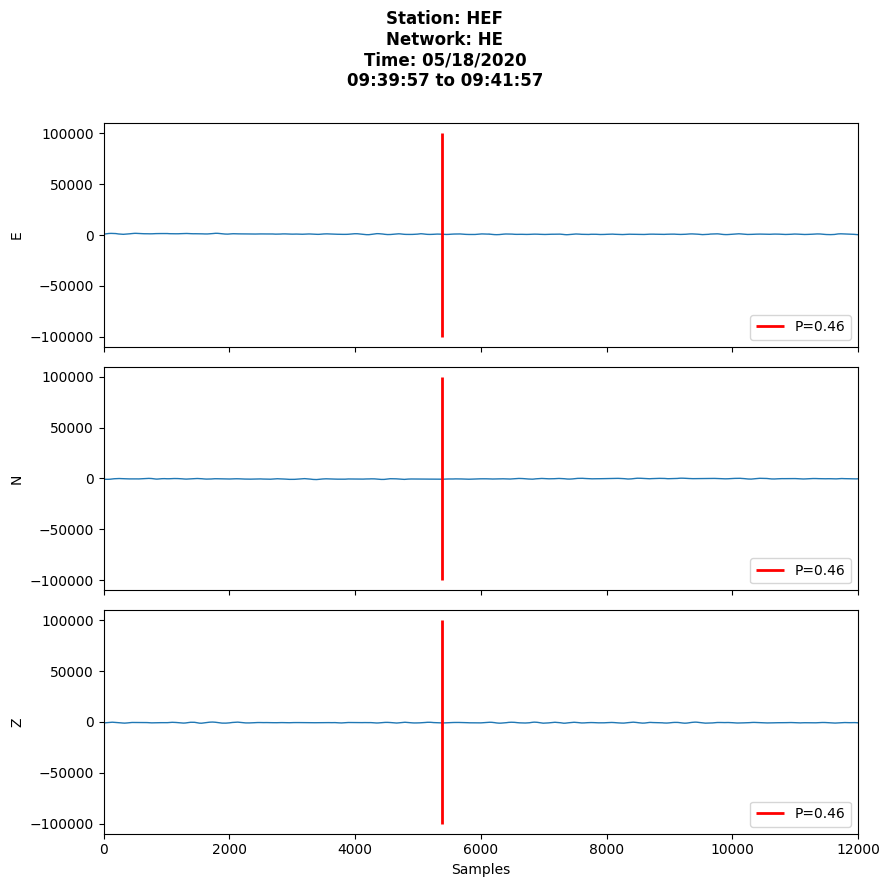

02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved


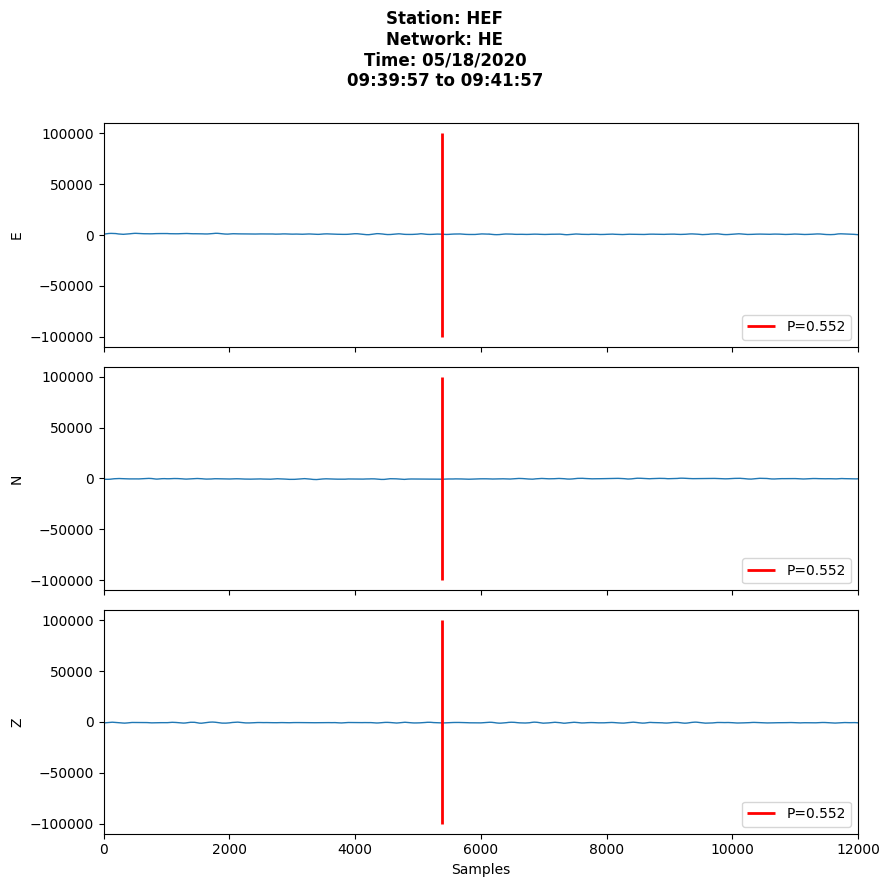

02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved


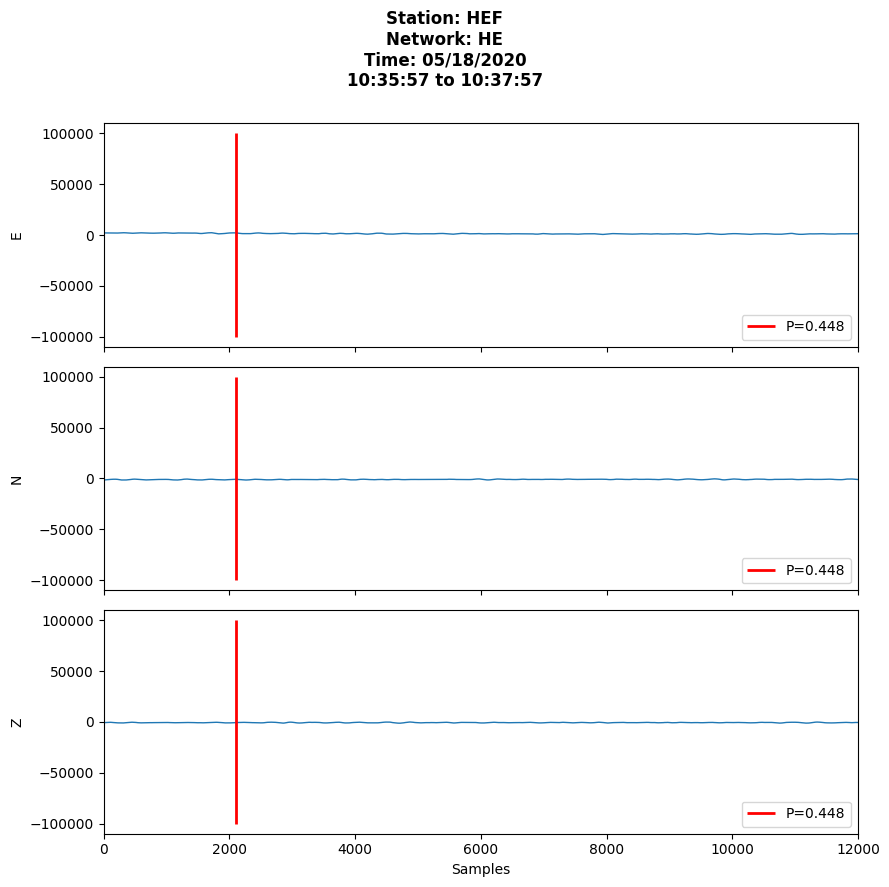

02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved


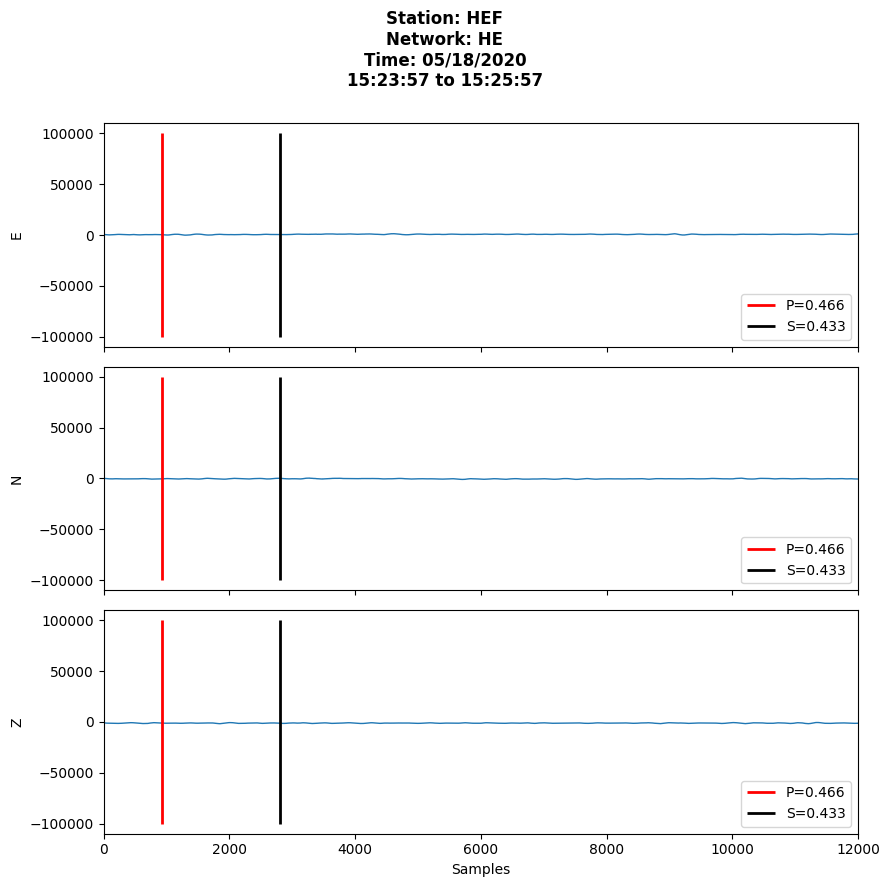

02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved
02-14 17:11 [DEBUG] [matplotlib.axes._base] top of Axes not in the figure, so title not moved


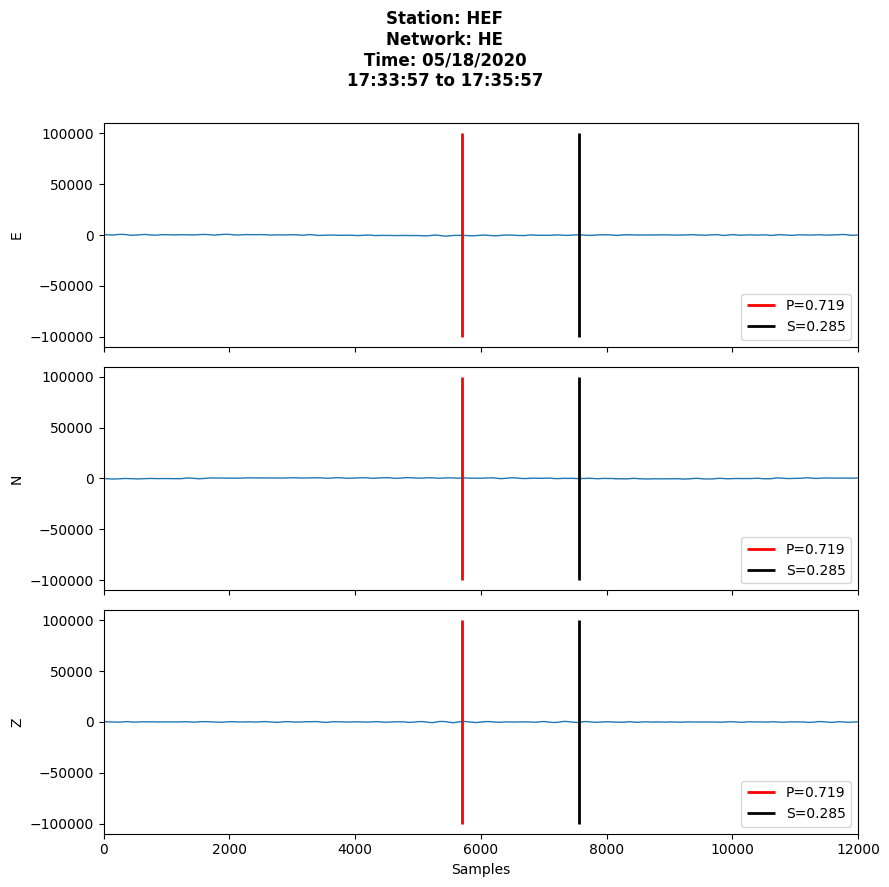

In [47]:
# Iterate over the filtered rows and plot the waveforms along with predicted picks
for idx, row in df_filtered.iterrows():

    # Extract filename from dataframe
    file_z = os.path.join(output_dir, row['file_name'])

    # Extract time-window part (after station folder)
    time_part = file_z.split('/')[-1].split('__')[1:]

    # Build glob pattern to get E/N/Z components
    station_folder = file_z.split('__')[0].rsplit('.', 1)[0]
    base_pattern = station_folder + ".*__" + "__".join(time_part)

    glo = sorted(glob.glob(base_pattern))

    if len(glo) == 0:
        continue

    # Read traces
    st = obspy.read(glo[0])
    for g in glo[1:]:
        st += obspy.read(g)

    st.merge(method=1, fill_value="interpolate")

    # Convert predicted arrival times to sample indices
    starttime = st[0].stats.starttime
    endtime = st[0].stats.endtime
    sampling_rate = st[0].stats.sampling_rate

    # No reference P-/S-picks available in this case
    refP = None
    refS = None

    # If there is a predicted arrival time, set the picks by computing the waveform sample index
    if pd.notna(row['p_arrival_time']):
        refP = int((UTCDateTime(row['p_arrival_time']) - starttime) * sampling_rate)

    if pd.notna(row['s_arrival_time']):
        refS = int((UTCDateTime(row['s_arrival_time']) - starttime) * sampling_rate)

    # Extract date and time information
    window_date = starttime.strftime("%m/%d/%Y")
    window_start = starttime.strftime("%H:%M:%S")
    window_end = endtime.strftime("%H:%M:%S")

    # === Plot ===
    fig = plt.figure(figsize=(9, 9))

    # Event info to generate a plot title
    event_info = f"Station: {st[0].stats.station}\nNetwork: {st[0].stats.network}\nTime: {window_date}\n{window_start} to {window_end}\n"
    fig.suptitle(event_info, fontsize=12, fontweight='bold')

    # Plot each channel separately
    for i, comp_label in enumerate(['E', 'N', 'Z']):
        ax = plt.subplot(3, 1, i + 1)
        plt.plot(st[i].data, linewidth=1)

        # Manually set y-axis limit rather high (to allow distinguishing noise from actual events)
        ymin = -1e5
        ymax = 1e5

        # Plot vertical lines for predicted p- and s-wave arrivals
        if refP is not None:
            plt.vlines(refP, ymin, ymax, color='r', linewidth=2, label=f'P={row["p_probability"]}')

        if refS is not None:
            plt.vlines(refS, ymin, ymax, color='k', linewidth=2, label=f'S={row["s_probability"]}')

        # Set x limit as the number of samples 100Hz -> 6000 per minute
        ax.set_xlim(0, len(st[i].data))
        ax.set_ylabel(comp_label)

        # Hide x-axis labels for the first two channels (only show for the last channel)
        if i < 2:
            plt.setp(ax.get_xticklabels(), visible=False)

        ax.legend(loc='lower right')
    plt.xlabel("Samples")
    plt.tight_layout()
    plt.show()
